# MATH GR 5320 - TA / Grader Demo Notebook

**Purpose:** Reproduce all risk outputs for any portfolio.  The default config pulls MSFT + JPM from Yahoo Finance - no local files needed.  Swap in your own data in **§ 1 · Configuration** and run all cells.

---

## Quick Start - Setup

Run these commands once from the repo root, then come back here:

```bash
# 1. Install dependencies
pip install -r requirements.txt
pip install ipykernel matplotlib

# 2. Register the kernel (so Jupyter sees the right Python)
python -m ipykernel install --user --name math5320 --display-name "Python (math5320)"

# 3. Launch Jupyter
jupyter notebook notebooks/ta_grader_demo.ipynb
```

Then: **Kernel → Change kernel → Python (math5320)** and run all cells.

---

### Supported data formats

| Format | Example | Notes |
|---|---|---|
| Bloomberg single-ticker | `MSFT-bloomberg.csv` | `Dates` column + `PX_LAST` price column |
| Bloomberg multi-ticker | `prices.csv` | `Date` + one column per ticker |
| Yahoo Finance (default) | - | No CSV needed; set `USE_YFINANCE = True` |

### Option positions
Fill in `OPTION_SPECS` in **§ 1 · Configuration**.  Leave the list empty (`[]`) for a stocks-only portfolio.

---

## § 1 · Configuration  ← **Edit this cell**

Everything the grader needs to change lives here.  Once filled in, run all remaining cells.

In [1]:
# ── § 1 · CONFIGURATION ─────────────────────────────────────────────────────
#
# Edit the values below to match your dataset.  All other cells are read-only.

# ── 1a. Price data ──────────────────────────────────────────────────────────

# Option A: Bloomberg single-ticker CSVs in ../data/
#   Each file must have a 'Dates' column and a 'PX_LAST' column.
#   Set to {} to skip (default - uses Yahoo Finance instead).
BLOOMBERG_SINGLE_FILES = {}     # e.g. {"MSFT": "MSFT-bloomberg", "JPM": "JPM-bloomberg"}

# Option B: Wide-format CSV (Date, TICKER1, TICKER2, ...)
#   Set to None to skip.
WIDE_CSV_PATH = None            # e.g. "../data/prices.csv"

# Option C: Download from Yahoo Finance (requires internet)
#   Used when both A and B are unavailable or empty.
USE_YFINANCE     = True         # True = pull from Yahoo Finance
YFINANCE_TICKERS = ["MSFT", "JPM"]
YFINANCE_START   = "2015-01-01"
YFINANCE_END     = "2024-12-31"


# ── 1b. Stock positions ─────────────────────────────────────────────────────
#
# List of (ticker, quantity) pairs.
# Ticker must match a column in the loaded price DataFrame.
STOCK_POSITIONS = [
    ("MSFT",  5000),    # shares of Microsoft
    ("JPM",   3000),    # shares of JPMorgan Chase
]


# ── 1c. Option positions ─────────────────────────────────────────────────────
#
# Each dict maps to one OptionPosition.  Leave as [] for stocks-only.
#
# Fields:
#   ticker              - unique label for this option contract
#   underlying          - must match a column in the price data
#   option_type         - "call" or "put"
#   quantity            - signed number of contracts (negative = short)
#   strike              - strike price in dollars
#   maturity_date       - expiry date as "YYYY-MM-DD"
#   volatility          - implied volatility as a decimal (e.g. 0.25 = 25%)
#   risk_free_rate      - continuously-compounded rate (e.g. 0.045 = 4.5%)
#   dividend_yield      - continuous dividend yield (e.g. 0.008 = 0.8%)
#   contract_multiplier - shares per contract (100 for US equity options)

OPTION_SPECS = [
    {
        "ticker":              "MSFT_C_450_JUN26",
        "underlying":          "MSFT",
        "option_type":         "call",
        "quantity":            10,           # long 10 contracts
        "strike":              450.0,
        "maturity_date":       "2026-06-19",
        "volatility":          0.28,
        "risk_free_rate":      0.045,
        "dividend_yield":      0.008,
        "contract_multiplier": 100,
    },
    {
        "ticker":              "JPM_P_180_DEC25",
        "underlying":          "JPM",
        "option_type":         "put",
        "quantity":            -5,           # short 5 contracts (writing puts)
        "strike":              180.0,
        "maturity_date":       "2025-12-19",
        "volatility":          0.24,
        "risk_free_rate":      0.045,
        "dividend_yield":      0.022,
        "contract_multiplier": 100,
    },
    # Add more options here, or delete entries for a stocks-only portfolio
]


# ── 1d. Pricing date ─────────────────────────────────────────────────────────
#
# Date used for Black-Scholes option pricing.
# Use None to auto-select the last date available in the price history.

PRICING_DATE_STR = None         # e.g. "2024-10-14" or None for auto


# ── 1e. Risk parameters ──────────────────────────────────────────────────────

LOOKBACK_DAYS      = 252        # rolling estimation window (trading days)
HORIZON_DAYS       = 10         # VaR/ES horizon (trading days)
VAR_CONFIDENCE     = 0.99       # e.g. 0.99 for 1% tail
ES_CONFIDENCE      = 0.975      # e.g. 0.975 for 2.5% tail
ESTIMATOR          = "window"   # "window" or "ewma"
EWMA_N             = 60         # EWMA decay; only used when ESTIMATOR="ewma"
N_SIMULATIONS      = 10_000     # Monte Carlo paths
RANDOM_SEED        = 42         # reproducibility; set to None for random
BACKTEST_MAX_YEARS = 5          # limit backtest to last N years (keeps runtime <60s)


# ── 1f. Manual calibration (optional) ───────────────────────────────────────
#
# Set USE_MANUAL_PARAMS = True to bypass historical estimation and supply
# your own daily mean and covariance (e.g. from the homework problem set).
#
# IMPORTANT: keys must match the ticker names in STOCK_POSITIONS / OPTION_SPECS.

USE_MANUAL_PARAMS = False

MANUAL_MARKET_PARAMS = {
    "mu_daily": {
        "MSFT": 0.00040,
        "JPM":  0.00030,
    },
    "cov_daily": {
        "MSFT": {"MSFT": 4.2e-4, "JPM": 1.8e-4},
        "JPM":  {"MSFT": 1.8e-4, "JPM": 3.5e-4},
    },
}

print("Configuration loaded.")

Configuration loaded.


---
## § 2 · Setup

Run once.  No changes needed.

In [2]:
import os, sys
from pathlib import Path

# Add project root to Python path so `src.*` imports work
ROOT = str(Path(os.getcwd()).parent.resolve())
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from datetime import date, datetime
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.schemas import Portfolio, StockPosition, OptionPosition
from src.data.market_data import download_adjusted_close
from src.services.risk_engine_service import RiskEngineService
from src.risk.backtest import kupiec_test, conditional_coverage_test, basel_traffic_light
from src.portfolio.portfolio import portfolio_value

DATA_DIR = os.path.join(ROOT, "data")
print(f"Project root : {ROOT}")
print(f"Data dir     : {DATA_DIR}")

Project root : /Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5320/Project/MATH5320
Data dir     : /Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5320/Project/MATH5320/data


---
## § 3 · Load price data

In [3]:
def _load_bloomberg_single(files: dict, data_dir: str) -> pd.DataFrame | None:
    """Load multiple Bloomberg single-ticker CSVs and merge into one DataFrame."""
    frames = {}
    for ticker, stem in files.items():
        path = os.path.join(data_dir, f"{stem}.csv")
        if not os.path.exists(path):
            print(f"  ⚠  {path} not found - skipping {ticker}")
            continue
        df = pd.read_csv(path, parse_dates=["Dates"], dayfirst=False)
        df = df.set_index("Dates").sort_index()
        # Replace Bloomberg 'N/A' strings with NaN, then take PX_LAST
        col = df["PX_LAST"].replace("#N/A N/A", pd.NA)
        frames[ticker] = pd.to_numeric(col, errors="coerce")
        print(f"  ✓  {ticker}: {len(df):,} rows from {df.index[0].date()} to {df.index[-1].date()}")
    if not frames:
        return None
    prices = pd.DataFrame(frames).dropna(how="any")
    prices.index = pd.to_datetime(prices.index)
    return prices.sort_index()


def _load_wide_csv(path: str) -> pd.DataFrame:
    """Load a wide-format CSV (Date, TICKER1, TICKER2, ...) as a price DataFrame."""
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    df.index = pd.to_datetime(df.index)
    return df.apply(pd.to_numeric, errors="coerce").dropna(how="any").sort_index()


# ── Load in priority order: single-file Bloomberg -> wide CSV -> yfinance ──────
prices = None

if BLOOMBERG_SINGLE_FILES:
    print("Loading Bloomberg single-ticker CSVs…")
    prices = _load_bloomberg_single(BLOOMBERG_SINGLE_FILES, DATA_DIR)

if prices is None and WIDE_CSV_PATH is not None:
    print(f"Loading wide CSV: {WIDE_CSV_PATH}")
    prices = _load_wide_csv(WIDE_CSV_PATH)

if prices is None and USE_YFINANCE:
    print(f"Downloading from Yahoo Finance: {YFINANCE_TICKERS}…")
    prices = download_adjusted_close(YFINANCE_TICKERS, YFINANCE_START, YFINANCE_END)

if prices is None or prices.empty:
    raise RuntimeError(
        "No price data loaded.  Check your CSV paths or set USE_YFINANCE = True."
    )

# ── Summary ──────────────────────────────────────────────────────────────────
print(f"\nPrice DataFrame: {prices.shape[0]:,} rows * {prices.shape[1]} tickers")
print(f"Date range     : {prices.index[0].date()} -> {prices.index[-1].date()}")
print(f"Tickers        : {list(prices.columns)}")
prices.tail(3)


Price DataFrame: 2,515 rows × 2 tickers
Date range     : 2015-01-02 → 2024-12-30
Tickers        : ['JPM', 'MSFT']


Ticker,JPM,MSFT
Date,,
2024-12-26,235.823608,433.911438
2024-12-27,233.912872,426.404053
2024-12-30,232.118576,420.758698


---
## § 4 · Build portfolio

In [4]:
# ── Pricing date ─────────────────────────────────────────────────────────────
if PRICING_DATE_STR is None:
    pricing_date = prices.index[-1].date()
else:
    pricing_date = datetime.strptime(PRICING_DATE_STR, "%Y-%m-%d").date()

print(f"Pricing date: {pricing_date}")

# ── Stock positions ───────────────────────────────────────────────────────────
stocks = [StockPosition(ticker=t, quantity=q) for t, q in STOCK_POSITIONS]

# ── Option positions ──────────────────────────────────────────────────────────
options = [
    OptionPosition(
        ticker          = spec["ticker"],
        underlying_ticker = spec["underlying"],
        option_type     = spec["option_type"],
        quantity        = spec["quantity"],
        strike          = spec["strike"],
        maturity_date      = datetime.strptime(spec["maturity_date"], "%Y-%m-%d").date(),
        volatility      = spec["volatility"],
        risk_free_rate  = spec["risk_free_rate"],
        dividend_yield  = spec["dividend_yield"],
        contract_multiplier = spec["contract_multiplier"],
    )
    for spec in OPTION_SPECS
]

portfolio = Portfolio(stocks=stocks, options=options)

# ── Current portfolio value ───────────────────────────────────────────────────
spots = prices.iloc[-1]
V0 = portfolio_value(portfolio, spots, pricing_date)

print(f"\nPortfolio:")
print(f"  Stock legs   : {len(stocks)}")
print(f"  Option legs  : {len(options)}")
print(f"  Mark-to-market (V0) = ${V0:,.2f}")

Pricing date: 2024-12-30

Portfolio:
  Stock legs   : 2
  Option legs  : 2
  Mark-to-market (V0) = $2,852,495.98


In [5]:
# ── Portfolio composition table ───────────────────────────────────────────────
rows = []
for pos in portfolio.stocks:
    s = float(spots.get(pos.ticker, float("nan")))
    rows.append({
        "Leg": pos.ticker, "Type": "Stock",
        "Qty": pos.quantity, "Strike": " - ", "Maturity": " - ",
        "Vol": " - ", "MtM ($)": round(pos.quantity * s, 2),
    })

for pos in portfolio.options:
    from src.pricing.black_scholes import bs_price
    s = float(spots.get(pos.underlying_ticker, float("nan")))
    T = max((pos.maturity_date - pricing_date).days / 365.0, 1e-6)
    unit_val = bs_price(s, pos.strike, T, pos.risk_free_rate,
                        pos.dividend_yield, pos.volatility, pos.option_type)
    mtm = pos.quantity * pos.contract_multiplier * unit_val
    rows.append({
        "Leg": pos.ticker, "Type": f"{pos.option_type.capitalize()} option",
        "Qty": pos.quantity, "Strike": pos.strike, "Maturity": str(pos.maturity_date),
        "Vol": f"{pos.volatility:.0%}", "MtM ($)": round(mtm, 2),
    })

comp_df = pd.DataFrame(rows).set_index("Leg")
comp_df.style.format({"MtM ($)": "{:,.2f}"})

,Type,Qty,Strike,Maturity,Vol,MtM ($)
Leg,,,,,,
MSFT,Stock,5000.000000,-,-,-,"2,103,793.49"
JPM,Stock,3000.000000,-,-,-,"696,355.73"
MSFT_C_450_JUN26,Call option,10.000000,450.000000,2026-06-19,28%,"53,734.22"
JPM_P_180_DEC25,Put option,-5.000000,180.000000,2025-12-19,24%,"-1,387.46"


---
## § 5 · Risk analysis - all three models

In [6]:
svc = RiskEngineService(
    portfolio         = portfolio,
    prices            = prices,
    pricing_date      = pricing_date,
    lookback_days     = LOOKBACK_DAYS,
    horizon_days      = HORIZON_DAYS,
    var_confidence    = VAR_CONFIDENCE,
    es_confidence     = ES_CONFIDENCE,
    estimator         = ESTIMATOR,
    ewma_N            = EWMA_N,
    n_simulations     = N_SIMULATIONS,
    calibration_mode  = "manual" if USE_MANUAL_PARAMS else "historical",
    manual_market_params = MANUAL_MARKET_PARAMS if USE_MANUAL_PARAMS else None,
)

print("Running all three VaR/ES models…")
results = svc.run_all()
print("Done.")

Running all three VaR/ES models…


Done.


In [7]:
# ── Results summary table ─────────────────────────────────────────────────────
models = {
    "Historical Simulation": results["historical"],
    "Parametric (Delta-Normal)": results["parametric"],
    "Monte Carlo": results["monte_carlo"],
}

summary_rows = []
for name, res in models.items():
    summary_rows.append({
        "Model": name,
        f"VaR ({VAR_CONFIDENCE:.0%}) $": round(res["var"], 2),
        f"ES  ({ES_CONFIDENCE:.1%}) $": round(res["es"], 2),
        f"VaR / V0": f"{res['var']/V0:.3%}" if V0 else " - ",
        f"ES  / V0": f"{res['es']/V0:.3%}" if V0 else " - ",
    })

summary_df = pd.DataFrame(summary_rows).set_index("Model")
print(f"\nRisk Summary  |  lookback={LOOKBACK_DAYS}d  horizon={HORIZON_DAYS}d  V0=${V0:,.0f}")
print(f"Calibration: {'manual' if USE_MANUAL_PARAMS else f'historical ({ESTIMATOR})'} | "
      f"MC paths: {N_SIMULATIONS:,}")
summary_df


Risk Summary  |  lookback=252d  horizon=10d  V0=$2,852,496
Calibration: historical (window) | MC paths: 10,000


,VaR (99%) $,ES (97.5%) $,VaR / V0,ES / V0
Model,,,,
Historical Simulation,190002.63,214035.97,6.661%,7.503%
Parametric (Delta-Normal),218597.40,219784.02,7.663%,7.705%
Monte Carlo,210853.96,209061.59,7.392%,7.329%


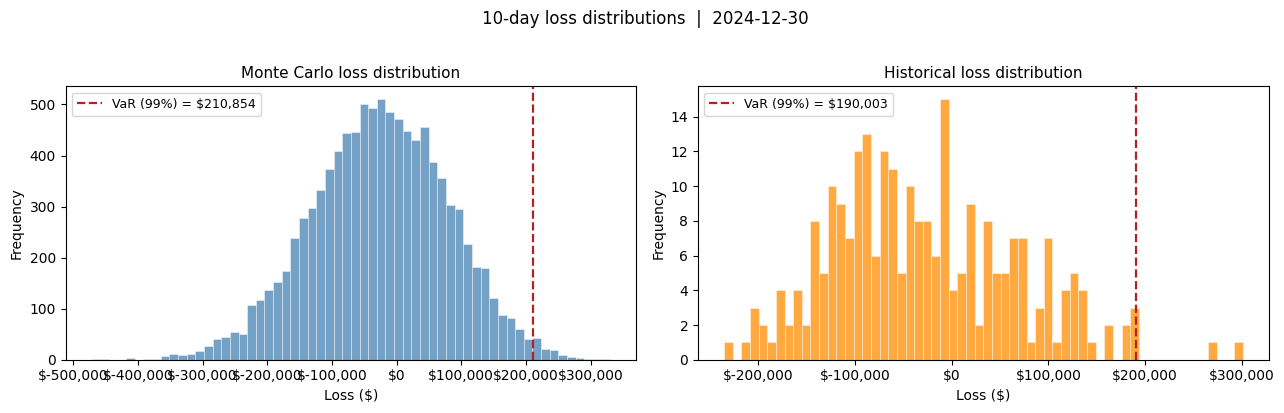

In [8]:
# ── Loss distribution chart (Monte Carlo) ─────────────────────────────────────
mc_losses = results["monte_carlo"]["losses"]
hist_losses = results["historical"]["losses"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, losses, title, color in [
    (axes[0], mc_losses,   "Monte Carlo loss distribution",  "steelblue"),
    (axes[1], hist_losses, "Historical loss distribution",   "darkorange"),
]:
    ax.hist(losses, bins=60, color=color, alpha=0.75, edgecolor="white", linewidth=0.4)
    var_line = np.quantile(losses, VAR_CONFIDENCE)
    ax.axvline(var_line, color="firebrick", linewidth=1.6, linestyle="--",
               label=f"VaR ({VAR_CONFIDENCE:.0%}) = ${var_line:,.0f}")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Loss ($)")
    ax.set_ylabel("Frequency")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.legend(fontsize=9)

plt.suptitle(f"{HORIZON_DAYS}-day loss distributions  |  {pricing_date}",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## § 6 · Backtest

In [9]:
# Choose which model to backtest: "historical", "parametric", or "monte_carlo"
BACKTEST_MODEL = "historical"

# Limit backtest window to keep runtime reasonable
bt_cutoff = prices.index[-1] - pd.DateOffset(years=BACKTEST_MAX_YEARS)
prices_bt = prices[prices.index >= bt_cutoff]
svc_bt = RiskEngineService(
    portfolio=portfolio, prices=prices_bt, pricing_date=pricing_date,
    lookback_days=LOOKBACK_DAYS, horizon_days=HORIZON_DAYS,
    var_confidence=VAR_CONFIDENCE, es_confidence=ES_CONFIDENCE,
    estimator=ESTIMATOR, ewma_N=EWMA_N, n_simulations=N_SIMULATIONS,
    calibration_mode="manual" if USE_MANUAL_PARAMS else "historical",
    manual_market_params=MANUAL_MARKET_PARAMS if USE_MANUAL_PARAMS else None,
)
print(f"Running walk-forward backtest ({BACKTEST_MODEL}, last {BACKTEST_MAX_YEARS}y)…")
bt = svc_bt.run_backtest(model=BACKTEST_MODEL)
print("Done.")

Running walk-forward backtest (historical, last 5y)…


Done.


In [10]:
bt_df = bt["backtest_df"]

if bt_df.empty:
    print("⚠  Backtest returned no data:", bt.get("reason"))
else:
    n_obs  = len(bt_df)
    n_exc  = int(bt_df["exception"].sum())
    kupiec = bt["kupiec"]
    cc     = bt["conditional_coverage"]
    sev    = bt["severity"]
    zone   = bt["basel"]

    print(f"Backtest window  : {bt_df['date'].iloc[0]} -> {bt_df['date'].iloc[-1]}")
    print(f"Observations     : {n_obs}")
    print(f"Exceptions       : {n_exc}  "
          f"(rate {n_exc/n_obs:.2%} vs expected {1-VAR_CONFIDENCE:.2%})")
    print()
    print("Kupiec POF test")
    print(f"  LR statistic   : {kupiec['lr_stat']:.4f}")
    print(f"  p-value        : {kupiec['p_value']:.4f}")
    print(f"  Reject H₀      : {kupiec['reject_h0']}")
    print()
    print("Conditional Coverage (Christoffersen)")
    print(f"  LR_cc          : {cc['lr_cc']:.4f}")
    print(f"  p-value_cc     : {cc['p_value_cc']:.4f}")
    print(f"  Reject CC H₀   : {cc['reject_cc']}")
    print()
    if zone:
        print(f"Basel Traffic Light: {zone['zone']}  "
              f"(multiplier add-on = {zone.get('multiplier_addon', zone.get('multiplier', 0)):.2f})")
    print()
    print("Exception severity")
    print(f"  Mean gap (loss − VaR forecast) : ${sev['exception_gap']:,.2f}")
    print(f"  Average exception loss         : ${sev['average_exception_loss']:,.2f}")
    print(f"  Worst exception loss           : ${sev['max_exception_loss']:,.2f}")

Backtest window  : 2020-12-30 00:00:00 → 2024-12-13 00:00:00
Observations     : 996
Exceptions       : 32  (rate 3.21% vs expected 1.00%)

Kupiec POF test
  LR statistic   : 31.1145
  p-value        : 0.0000
  Reject H₀      : True

Conditional Coverage (Christoffersen)
  LR_cc          : 142.6092
  p-value_cc     : 0.0000
  Reject CC H₀   : True

Basel Traffic Light: RED  (multiplier add-on = 0.00)

Exception severity
  Mean gap (loss − VaR forecast) : $37,362.61
  Average exception loss         : $180,381.89
  Worst exception loss           : $309,139.69


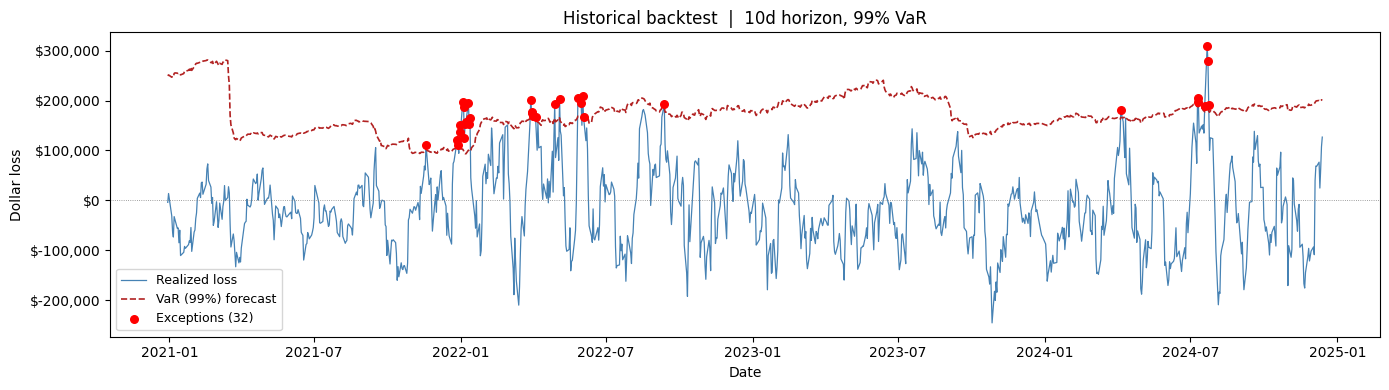

In [11]:
# ── Backtest chart: realized loss vs VaR forecast ─────────────────────────────
if not bt_df.empty:
    fig, ax = plt.subplots(figsize=(14, 4))

    ax.plot(bt_df["date"], bt_df["realized_loss"], color="steelblue",
            linewidth=0.9, label="Realized loss")
    ax.plot(bt_df["date"], bt_df["var_forecast"],  color="firebrick",
            linewidth=1.2, linestyle="--", label=f"VaR ({VAR_CONFIDENCE:.0%}) forecast")

    exc_mask = bt_df["exception"].astype(bool)
    ax.scatter(bt_df.loc[exc_mask, "date"], bt_df.loc[exc_mask, "realized_loss"],
               color="red", s=30, zorder=5, label=f"Exceptions ({exc_mask.sum()})")

    ax.axhline(0, color="gray", linewidth=0.6, linestyle=":")
    ax.set_title(f"{BACKTEST_MODEL.replace('_', ' ').title()} backtest  |  "
                 f"{HORIZON_DAYS}d horizon, {VAR_CONFIDENCE:.0%} VaR")
    ax.set_xlabel("Date")
    ax.set_ylabel("Dollar loss")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

---
## § 7 · Exact GBM VaR / ES (closed-form lognormal)

Single-asset closed-form VaR and ES using the exact GBM formula from §4 / §7 of the formula sheet.  Useful for spot-checking against the homework goldens.

In [12]:
from src.risk.lognormal import (
    var_long_lognormal, es_long_lognormal,
    var_short_lognormal, es_short_lognormal,
)
from src.risk.estimators import get_mean_cov
from src.risk.returns import compute_log_returns

# ── Per-ticker GBM VaR / ES ────────────────────────────────────────────────
h = HORIZON_DAYS / 252           # horizon in years
log_ret = compute_log_returns(prices)
mu_daily, cov_daily = get_mean_cov(log_ret, LOOKBACK_DAYS, ESTIMATOR, EWMA_N)

rows_gbm = []
for ticker in prices.columns:
    spot = float(prices[ticker].iloc[-1])

    # Find the matching stock position to get notional
    qty = next(
        (pos.quantity for pos in portfolio.stocks if pos.ticker == ticker), 1
    )
    V0_single = abs(qty) * spot
    direction = "long" if qty > 0 else "short"

    mu_ann    = float(mu_daily[ticker]) * 252
    sigma_ann = float(np.sqrt(cov_daily.loc[ticker, ticker] * 252))

    if direction == "long":
        var_gbm = var_long_lognormal(V0_single, mu_ann, sigma_ann, h, VAR_CONFIDENCE)
        es_gbm  = es_long_lognormal(V0_single, mu_ann, sigma_ann, h, ES_CONFIDENCE)
    else:
        var_gbm = var_short_lognormal(V0_single, mu_ann, sigma_ann, h, VAR_CONFIDENCE)
        es_gbm  = es_short_lognormal(V0_single, mu_ann, sigma_ann, h, ES_CONFIDENCE)

    rows_gbm.append({
        "Ticker": ticker, "Qty": qty, "Spot": spot,
        "mu_ann": f"{mu_ann:.4f}", "sigma_ann": f"{sigma_ann:.4f}",
        "Position": direction,
        f"GBM VaR ({VAR_CONFIDENCE:.0%}) $": round(var_gbm, 2),
        f"GBM ES  ({ES_CONFIDENCE:.1%}) $": round(es_gbm, 2),
    })

gbm_df = pd.DataFrame(rows_gbm).set_index("Ticker")
gbm_df

,Qty,Spot,μ_ann,σ_ann,Position,GBM VaR (99%) $,GBM ES (97.5%) $
Ticker,,,,,,,
JPM,3000.0,232.118576,0.3638,0.2332,long,62930.62,63188.54
MSFT,5000.0,420.758698,0.1315,0.2005,long,178183.80,178886.70


---
## § 8 · Manual calibration spot-check

Useful when the grader wants to verify the system against specific μ / Σ values from the problem set.

In [13]:
if USE_MANUAL_PARAMS:
    from src.risk.parametric import parametric_var_es

    res_manual = parametric_var_es(
        portfolio         = portfolio,
        prices            = prices,
        pricing_date      = pricing_date,
        lookback_days     = LOOKBACK_DAYS,
        horizon_days      = HORIZON_DAYS,
        var_confidence    = VAR_CONFIDENCE,
        es_confidence     = ES_CONFIDENCE,
        calibration_mode  = "manual",
        manual_market_params = MANUAL_MARKET_PARAMS,
    )

    print("Parametric VaR/ES with MANUAL market parameters:")
    print(f"  VaR ({VAR_CONFIDENCE:.0%}) = ${res_manual['var']:,.2f}")
    print(f"  ES  ({ES_CONFIDENCE:.1%}) = ${res_manual['es']:,.2f}")
    print(f"  Portfolio mean P&L (h={HORIZON_DAYS}d) = ${res_manual['mean_pnl']:,.2f}")
    print(f"  Portfolio sigma P&L    (h={HORIZON_DAYS}d) = ${res_manual['std_pnl']:,.2f}")
else:
    print("USE_MANUAL_PARAMS = False - skip this cell or set it to True in § 1.")

USE_MANUAL_PARAMS = False - skip this cell or set it to True in § 1.


---
## § 9 · Appendix - Full parameter reference

All parameters with type constraints and default values, for reference when filling in § 1.

| Parameter | Type | Constraint | Default |
|---|---|---|---|
| `BLOOMBERG_SINGLE_FILES` | dict | `{ticker: csv_stem}` | `{}` |
| `WIDE_CSV_PATH` | str \| None | path to wide CSV | `None` |
| `USE_YFINANCE` | bool | - | `True` |
| `YFINANCE_TICKERS` | list[str] | - | `["AAPL","CAT"]` |
| `YFINANCE_START/END` | str | `"YYYY-MM-DD"` | last 2 years |
| `STOCK_POSITIONS` | list[(str, int)] | quantity can be negative | - |
| `OPTION_SPECS` | list[dict] | see table below | `[]` |
| `PRICING_DATE_STR` | str \| None | `"YYYY-MM-DD"` or `None` | `None` (latest date) |
| `LOOKBACK_DAYS` | int | ≥ 1 | `252` |
| `HORIZON_DAYS` | int | ≥ 1 | `10` |
| `VAR_CONFIDENCE` | float | (0, 1) | `0.99` |
| `ES_CONFIDENCE` | float | (0, 1) | `0.975` |
| `ESTIMATOR` | str | `"window"` or `"ewma"` | `"window"` |
| `EWMA_N` | int | ≥ 2 | `60` |
| `N_SIMULATIONS` | int | ≥ 100 | `10_000` |
| `RANDOM_SEED` | int \| None | - | `42` |
| `USE_MANUAL_PARAMS` | bool | - | `False` |

**`OPTION_SPECS` dict keys:**

| Key | Type | Constraint |
|---|---|---|
| `ticker` | str | unique label |
| `underlying` | str | must be in price data |
| `option_type` | str | `"call"` or `"put"` |
| `quantity` | int | negative = short |
| `strike` | float | > 0 |
| `maturity_date` | str | `"YYYY-MM-DD"` |
| `volatility` | float | > 0 (e.g. 0.25 = 25%) |
| `risk_free_rate` | float | continuous rate |
| `dividend_yield` | float | continuous yield (0 if none) |
| `contract_multiplier` | int | 100 for US equity options |